# 01 · Exploratory Data Analysis

Inspect the Tier 2 synthetic returns dataset — a regime-switching
multivariate Gaussian DGP with 5 long-history assets and 3 short-history
assets that start at row 3000.

This notebook covers: data loading, missingness pattern, per-asset
statistics, correlations, and rolling volatility.

In [1]:
# --- preamble ----------------------------------------------------------
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)

# Path to Tier 2 synthetic data (relative to this notebook)
TIER2_DIR = Path.cwd().parent.parent / "synthetic_data_generator" / "output" / "tier2"
TIER2_CSV = TIER2_DIR / "returns.csv"
TIER2_COMPLETE = TIER2_DIR / "returns_complete.csv"
TIER2_GT = TIER2_DIR / "ground_truth.json"
assert TIER2_CSV.exists(), f"Tier 2 fixture missing: {TIER2_CSV}"

## Load the dataset

In [2]:
from backcast.data.loader import load_backcast_dataset

ds = load_backcast_dataset(TIER2_CSV)

print(f"Total shape       : {ds.returns_full.shape}")
print(f"Long  ({ds.n_long:>2}) assets : {ds.long_assets}")
print(f"Short ({ds.n_short:>2}) assets : {ds.short_assets}")
print(f"Overlap           : {ds.overlap_start.date()} → {ds.overlap_end.date()}  "
      f"({ds.overlap_length} rows)")
print(f"Backcast          : first {ds.backcast_length} rows")
print(f"Short start indices: {ds.short_start_indices}")

Total shape       : (5000, 8)
Long  ( 5) assets : ['EQUITY_1', 'EQUITY_2', 'BOND_1', 'BOND_2', 'GOLD']
Short ( 3) assets : ['ALT_1', 'CRYPTO_1', 'CRYPTO_2']
Overlap           : 2001-07-03 → 2009-03-02  (2000 rows)
Backcast          : first 3000 rows
Short start indices: {'ALT_1': 3000, 'CRYPTO_1': 3000, 'CRYPTO_2': 3000}


## Missingness pattern

The Tier 2 data has a classic monotone block: long assets observed for
all 5000 rows, short assets starting simultaneously at row 3000.

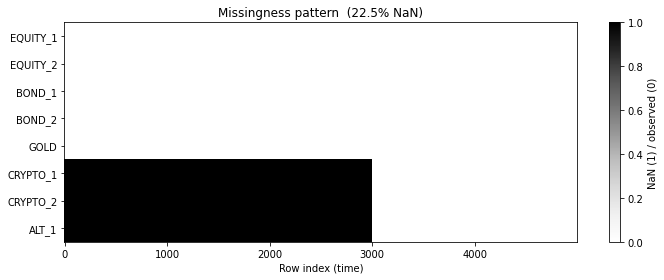

In [3]:
from backcast.visualization.plots import plot_missingness
fig = plot_missingness(ds.returns_full)
plt.show()

## Per-asset descriptive statistics

In [4]:
desc = ds.returns_full.describe(percentiles=[0.05, 0.5, 0.95]).T
desc["ann_vol_%"] = ds.returns_full.std() * np.sqrt(252) * 100
desc["ann_mean_%"] = ds.returns_full.mean() * 252 * 100
desc[["count", "ann_mean_%", "ann_vol_%", "5%", "95%"]].round(3)

,count,ann_mean_%,ann_vol_%,5%,95%
EQUITY_1,5000.0,-3.191,26.927,-0.027,0.027
EQUITY_2,5000.0,-2.836,30.335,-0.031,0.031
BOND_1,5000.0,3.945,8.045,-0.008,0.008
BOND_2,5000.0,5.965,11.218,-0.011,0.011
GOLD,5000.0,1.086,24.989,-0.025,0.025
CRYPTO_1,2000.0,10.782,112.394,-0.110,0.110
CRYPTO_2,2000.0,-13.733,106.665,-0.116,0.103
ALT_1,2000.0,-17.408,40.399,-0.042,0.038


## Annualized volatility — bar chart

Long assets (equities / bonds / gold) sit in the 5 – 20 % range; the
short-history crypto assets are in the 60 – 70 % range by construction.

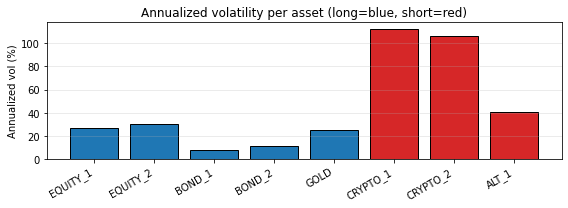

In [5]:
ann_vol = (ds.returns_full.std() * np.sqrt(252) * 100)
fig, ax = plt.subplots(figsize=(8, 3))
colors = ["C0"] * ds.n_long + ["C3"] * ds.n_short
ax.bar(range(len(ann_vol)), ann_vol.values, color=colors, edgecolor="k")
ax.set_xticks(range(len(ann_vol)))
ax.set_xticklabels(ann_vol.index, rotation=30, ha="right")
ax.set_ylabel("Annualized vol (%)")
ax.set_title("Annualized volatility per asset (long=blue, short=red)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Correlation matrix (overlap period)

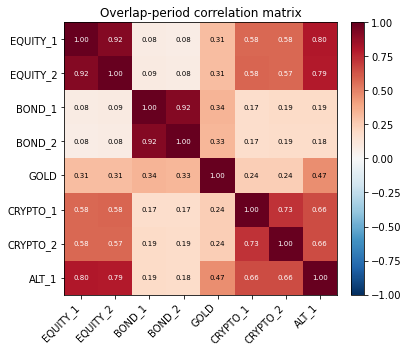

In [6]:
overlap_corr = ds.overlap_matrix.corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(overlap_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(overlap_corr)))
ax.set_xticklabels(overlap_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(overlap_corr)))
ax.set_yticklabels(overlap_corr.columns)
for i in range(len(overlap_corr)):
    for j in range(len(overlap_corr)):
        ax.text(j, i, f"{overlap_corr.iat[i,j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(overlap_corr.iat[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
ax.set_title("Overlap-period correlation matrix")
plt.tight_layout()
plt.show()

## Rolling volatility

63-day rolling annualized vol for long and short assets.  Peaks visible
in both groups mark the crisis-regime draws — this is exactly what the
HMM should detect in the next notebook.

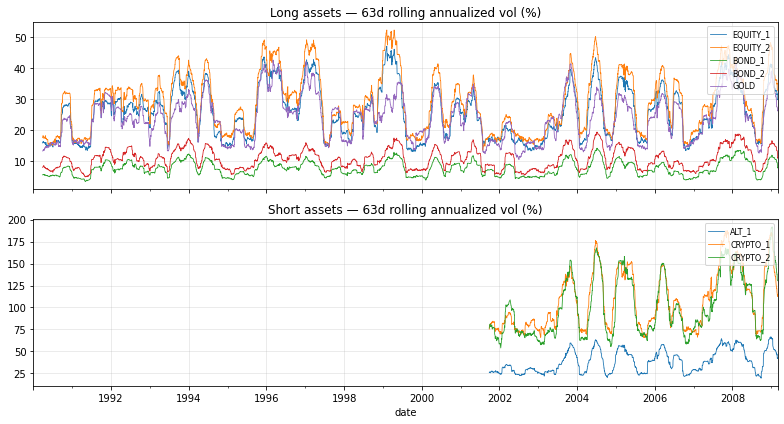

In [7]:
rolling_vol = ds.returns_full.rolling(63).std() * np.sqrt(252) * 100
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
rolling_vol[ds.long_assets].plot(ax=axes[0], lw=0.8)
rolling_vol[ds.short_assets].plot(ax=axes[1], lw=0.8)
axes[0].set_title("Long assets — 63d rolling annualized vol (%)")
axes[1].set_title("Short assets — 63d rolling annualized vol (%)")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## Cumulative returns

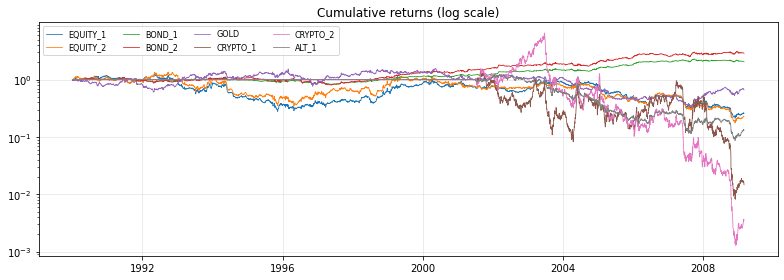

In [8]:
filled_forward = ds.returns_full.fillna(0.0)  # treat leading NaNs as zero-growth
cum = (1.0 + filled_forward).cumprod()
fig, ax = plt.subplots(figsize=(11, 4))
for col in ds.returns_full.columns:
    ax.plot(cum.index, cum[col], label=col, lw=0.8)
ax.set_yscale("log")
ax.set_title("Cumulative returns (log scale)")
ax.legend(fontsize=8, ncol=4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

- **Long assets** (equities, bonds, gold) have annualized vol 3 – 18 %,
  plausible for those asset classes.
- **Short assets** (crypto, alt) are high-vol by design (25 – 70 % ann.).
- Missingness is monotone — no mid-series gaps — which is what the
  backcast engine's Stambaugh EM is built for.
- Rolling vol shows occasional regime-like spikes: the next notebook
  will fit an HMM to identify these explicitly.